In [13]:
import numpy as np
import torch

from scipy.linalg import expm


In [2]:
def rhs_13_torch(y: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    A, B, C, D, E, F, G, H, I, J, K, L, M = y.unbind(dim=-1)
    (
        kf1, kf2, kf3, kf4, kf5, kf6, kf7, kf8, kf9, kf10, kf11, kf12,
        kr1, kr3, kr5, kr7, kr9, kr11, kr12
    ) = theta.unbind(dim=-1)

    dA = -kf1 * A + kr1 * B
    dB =  kf1 * A - kr1 * B - kf2 * B
    dC =  kf2 * B - kf3 * C + kr3 * D
    dD =  kf3 * C - kr3 * D - kf4 * D
    dE =  kf4 * D - kf5 * E + kr5 * F
    dF =  kf5 * E - kr5 * F - kf6 * F
    dG =  kf6 * F - kf7 * G + kr7 * H
    dH =  kf7 * G - kr7 * H - kf8 * H
    dI =  kf8 * H - kf9 * I + kr9 * J
    dJ =  kf9 * I - kr9 * J - kf10 * J
    dK =  kf10 * J - kf11 * K + kr11 * L
    dL =  kf11 * K - kr11 * L - kf12 * L + kr12 * M
    dM =  kf12 * L - kr12 * M
    return torch.stack([dA, dB, dC, dD, dE, dF, dG, dH, dI, dJ, dK, dL, dM], dim=-1)

In [ ]:

# Reproduce the exact theta_true used by create_dataset.py (seed=42, uniform(0.5, 1.5), n_params=19)
# Order: kf1..kf12, kr1, kr3, kr5, kr7, kr9, kr11, kr12
rng = np.random.default_rng(42)
theta_true = rng.uniform(0.5, 1.5, size=19).astype(np.float32)

param_names = [
    "kf1","kf2","kf3","kf4","kf5","kf6","kf7","kf8","kf9","kf10","kf11","kf12",
    "kr1","kr3","kr5","kr7","kr9","kr11","kr12",
]
for name, val in zip(param_names, theta_true):
    print(f"{name:>6} = {val:.6f}")

kf1,kf2,kf3,kf4,kf5,kf6,kf7,kf8,kf9,kf10,kf11,kf12 = theta_true[:12]
kr1,kr3,kr5,kr7,kr9,kr11,kr12 = theta_true[12:]


   kf1 = 1.273956
   kf2 = 0.938878
   kf3 = 1.358598
   kf4 = 1.197368
   kf5 = 0.594177
   kf6 = 1.475622
   kf7 = 1.261140
   kf8 = 1.286064
   kf9 = 0.628114
  kf10 = 0.950386
  kf11 = 0.870798
  kf12 = 1.426765
   kr1 = 1.143865
   kr3 = 1.322762
   kr5 = 0.943414
   kr7 = 0.727239
   kr9 = 1.054585
  kr11 = 0.563817
  kr12 = 1.327631


In [ ]:
# As one matrix:
# Xdot = np.array([dA, dB, dC, dD, dE, dF, dG, dH, dI, dJ, dK, dL, dM])

K_matrix=np.array([
[-kf1,kr1,0,0,0,0,0,0,0,0,0,0,0],
[kf1,-(kr1+kf2),0,0,0,0,0,0,0,0,0,0,0],
[0,kf2,-kf3,kr3,0,0,0,0,0,0,0,0,0],
[0,0,kf3,-(kr3+kf4),0,0,0,0,0,0,0,0,0],
[0,0,0,kf4,-kf5,kr5,0,0,0,0,0,0,0],
[0,0,0,0,kf5,-(kr5+kf6),0,0,0,0,0,0,0],
[0,0,0,0,0,kf6,-kf7,kr7,0,0,0,0,0],
[0,0,0,0,0,0,kf7,-(kr7+kf8),0,0,0,0,0],
[0,0,0,0,0,0,0,kf8,-kf9,kr9,0,0,0],
[0,0,0,0,0,0,0,0,kf9,-(kr9+kf10),0,0,0],
[0,0,0,0,0,0,0,0,0,kf10,-kf11,kr11,0],
[0,0,0,0,0,0,0,0,0,0,kf11,-(kr11+kf12),kr12],
[0,0,0,0,0,0,0,0,0,0,0,kf12,-kr12],
])

In [ ]:
x0 = np.ones(13)   # start with 1 unit of every species

A,B,C,D,E,F,G,H,I,J,K,L,M = x0

# Regular equation representation

dA = -kf1 * A + kr1 * B
dB =  kf1 * A - kr1 * B - kf2 * B
dC =  kf2 * B - kf3 * C + kr3 * D
dD =  kf3 * C - kr3 * D - kf4 * D
dE =  kf4 * D - kf5 * E + kr5 * F
dF =  kf5 * E - kr5 * F - kf6 * F
dG =  kf6 * F - kf7 * G + kr7 * H
dH =  kf7 * G - kr7 * H - kf8 * H
dI =  kf8 * H - kf9 * I + kr9 * J
dJ =  kf9 * I - kr9 * J - kf10 * J
dK =  kf10 * J - kf11 * K + kr11 * L
dL =  kf11 * K - kr11 * L - kf12 * L + kr12 * M
dM =  kf12 * L - kr12 * M

In [7]:
manual = np.array([dA, dB, dC, dD, dE, dF, dG, dH, dI, dJ, dK, dL, dM])   # fill in the rest

In [12]:
matrix = K_matrix @ x0
print("matrix RHS:", matrix)

print("manual RHS:", manual)

matrix RHS: [-0.13009095 -0.80878758  0.9030422  -1.16153181  1.54660487 -1.82485902
  0.94172126 -0.75216329  1.71253538 -1.37685692  0.64340514  0.20784694
  0.09913385]
manual RHS: [-0.13009095 -0.80878747  0.9030422  -1.16153181  1.54660487 -1.82485914
  0.94172126 -0.75216323  1.71253538 -1.37685704  0.64340514  0.20784694
  0.09913385]


In [17]:
t = 5.0
x_t = expm(K_matrix * t) @ x0
print("x(t=5):", x_t)


x(t=5): [0.14607128 0.11093288 0.42437652 0.25924798 1.41525251 0.36510817
 0.75700757 0.49101893 2.20269567 0.69105624 1.936314   2.11673571
 2.08418279]


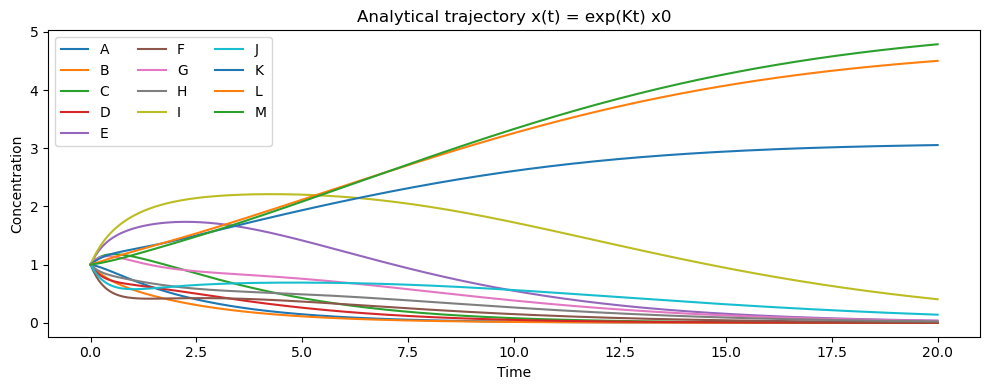

In [24]:
from scipy.linalg import expm
import matplotlib.pyplot as plt

species = ['A','B','C','D','E','F','G','H','I','J','K','L','M']
x0 = np.ones(13)  # start with 1 unit of everything
t_grid = np.linspace(0, 20, 300)

trajs = np.array([expm(K_matrix * t) @ x0 for t in t_grid])  # Analytical ODE solution

plt.figure(figsize=(10, 4))
for i, sp in enumerate(species):
    plt.plot(t_grid, trajs[:, i], label=sp)
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Analytical trajectory x(t) = exp(Kt) x0')
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

In [25]:
def build_K(theta):
    kf1,kf2,kf3,kf4,kf5,kf6,kf7,kf8,kf9,kf10,kf11,kf12 = theta[:12]
    kr1,kr3,kr5,kr7,kr9,kr11,kr12 = theta[12:]
    return np.array([
        [-kf1,kr1,0,0,0,0,0,0,0,0,0,0,0],
        [kf1,-(kr1+kf2),0,0,0,0,0,0,0,0,0,0,0],
        [0,kf2,-kf3,kr3,0,0,0,0,0,0,0,0,0],
        [0,0,kf3,-(kr3+kf4),0,0,0,0,0,0,0,0,0],
        [0,0,0,kf4,-kf5,kr5,0,0,0,0,0,0,0],
        [0,0,0,0,kf5,-(kr5+kf6),0,0,0,0,0,0,0],
        [0,0,0,0,0,kf6,-kf7,kr7,0,0,0,0,0],
        [0,0,0,0,0,0,kf7,-(kr7+kf8),0,0,0,0,0],
        [0,0,0,0,0,0,0,kf8,-kf9,kr9,0,0,0],
        [0,0,0,0,0,0,0,0,kf9,-(kr9+kf10),0,0,0],
        [0,0,0,0,0,0,0,0,0,kf10,-kf11,kr11,0],
        [0,0,0,0,0,0,0,0,0,0,kf11,-(kr11+kf12),kr12],
        [0,0,0,0,0,0,0,0,0,0,0,kf12,-kr12],
    ])

def get_sensitivity(theta, t, x0, param_idx, eps=1e-5):
    """Nudge theta_l by eps, see how x(t) changes."""
    theta_plus = theta.copy()
    theta_plus[param_idx] += eps
    x_base = expm(build_K(theta) * t) @ x0
    x_plus = expm(build_K(theta_plus) * t) @ x0
    return (x_plus - x_base) / eps   # shape (13,) — one number per species

In [26]:
t = 10.0
x0 = np.ones(13)

# S[i, l] = sensitivity of species i w.r.t. parameter l
S = np.zeros((13, 19))
for l in range(19):
    S[:, l] = get_sensitivity(theta_true, t, x0, l)

print("Sensitivity matrix shape:", S.shape)
print("Rows = species [A..M],  Columns = parameters [kf1..kr12]")

Sensitivity matrix shape: (13, 19)
Rows = species [A..M],  Columns = parameters [kf1..kr12]


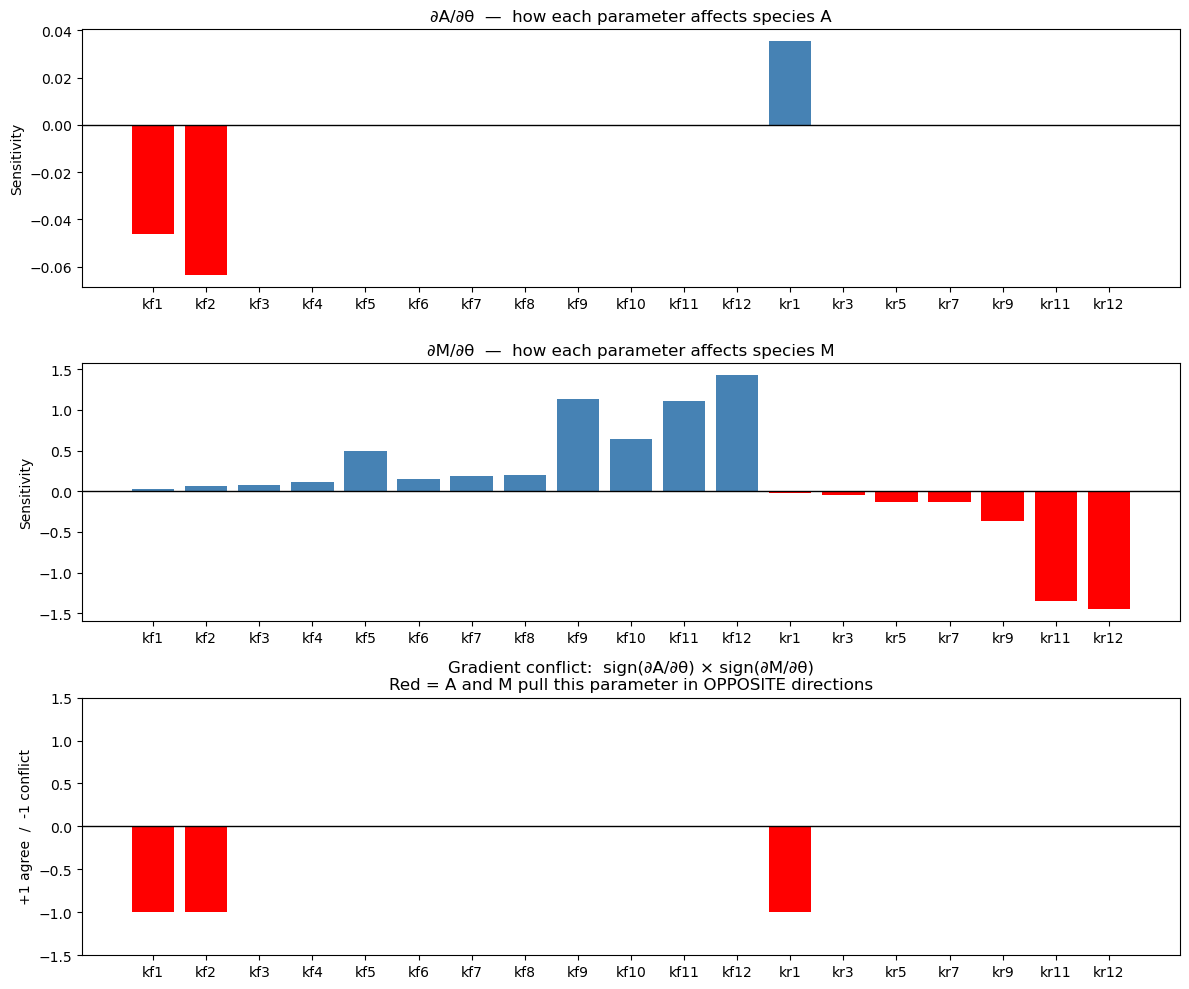

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Panel 1: sensitivity of A
ax = axes[0]
colors = ['red' if v < 0 else 'steelblue' for v in S[0, :]]
ax.bar(param_names, S[0, :], color=colors)
ax.axhline(0, color='k', lw=1)
ax.set_title('∂A/∂θ  —  how each parameter affects species A', fontsize=12)
ax.set_ylabel('Sensitivity')

# Panel 2: sensitivity of M
ax = axes[1]
colors = ['red' if v < 0 else 'steelblue' for v in S[12, :]]
ax.bar(param_names, S[12, :], color=colors)
ax.axhline(0, color='k', lw=1)
ax.set_title('∂M/∂θ  —  how each parameter affects species M', fontsize=12)
ax.set_ylabel('Sensitivity')

# Panel 3: conflict score — if opposite signs, bar is red
conflict = np.sign(S[0, :]) * np.sign(S[12, :])   # +1 = agree, -1 = conflict
colors = ['red' if v < 0 else 'green' for v in conflict]
ax = axes[2]
ax.bar(param_names, conflict, color=colors)
ax.axhline(0, color='k', lw=1)
ax.set_title('Gradient conflict:  sign(∂A/∂θ) × sign(∂M/∂θ)\nRed = A and M pull this parameter in OPPOSITE directions', fontsize=12)
ax.set_ylabel('+1 agree  /  -1 conflict')
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

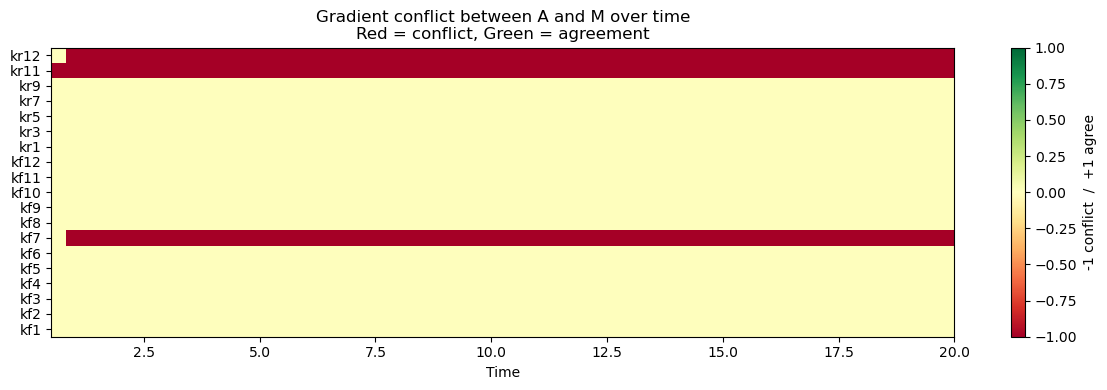

In [28]:
t_grid_short = np.linspace(0.5, 20, 60)
conflict_over_time = np.zeros((len(t_grid_short), 19))

for ti, t in enumerate(t_grid_short):
    S_t = np.zeros((13, 19))
    for l in range(19):
        S_t[:, l] = get_sensitivity(theta_true, t, x0, l)
    conflict_over_time[ti, :] = np.sign(S_t[0, :]) * np.sign(S_t[12, :])

plt.figure(figsize=(12, 4))
plt.imshow(conflict_over_time.T, aspect='auto', cmap='RdYlGn',
           vmin=-1, vmax=1,
           extent=[t_grid_short[0], t_grid_short[-1], -0.5, 18.5])
plt.yticks(range(19), param_names)
plt.xlabel('Time')
plt.title('Gradient conflict between A and M over time\nRed = conflict, Green = agreement')
plt.colorbar(label='-1 conflict  /  +1 agree')
plt.tight_layout()
plt.show()

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scaffolds import (rhs_2_torch, rhs_3_torch, rhs_5_torch, rhs_7_torch,
                       rhs_9_torch, rhs_11_torch, rhs_13_torch)

# ── all scaffolds to test, in order ───────────────────────────────────────────
scaffolds = [
    (2,  rhs_2_torch,  ("A","M"),              2),
    (3,  rhs_3_torch,  ("A","J","M"),          4),
    (5,  rhs_5_torch,  ("A","D","G","J","M"),  8),
    (7,  rhs_7_torch,  ("A","D","G","J","K","L","M"), 11),
    (9,  rhs_9_torch,  ("A","D","G","H","I","J","K","L","M"), 14),
    (11, rhs_11_torch, ("A","B","C","D","E","F","G","H","I","J","M"), 16),
    (13, rhs_13_torch, ("A","B","C","D","E","F","G","H","I","J","K","L","M"), 19),
]

def build_K_from_rhs(rhs, P, theta):
    """Extract K matrix by probing rhs with basis vectors."""
    B = theta.shape[0]
    cols = []
    for j in range(P):
        e_j = torch.zeros(B, P)
        e_j[:, j] = 1.0
        cols.append(rhs(e_j, theta))
    return torch.stack(cols, dim=-1)[0].numpy()  # (P, P)

def get_sensitivity_fd(rhs, P, theta_np, x0_np, t, obs_idx, eps=1e-5):
    """
    Finite difference sensitivity.
    Returns S shape (n_obs, n_theta):
        S[i, l] = d(x_obs_i)/d(theta_l)
    """
    n_theta = len(theta_np)
    n_obs = len(obs_idx)
    S = np.zeros((n_obs, n_theta))

    theta_t = torch.tensor(theta_np, dtype=torch.float32).unsqueeze(0)
    K_base = build_K_from_rhs(rhs, P, theta_t)
    x_base = expm(K_base * t) @ x0_np

    for l in range(n_theta):
        theta_plus = theta_np.copy()
        theta_plus[l] += eps
        theta_t2 = torch.tensor(theta_plus, dtype=torch.float32).unsqueeze(0)
        K_plus = build_K_from_rhs(rhs, P, theta_t2)
        x_plus = expm(K_plus * t) @ x0_np
        deriv = (x_plus - x_base) / eps
        for i, oi in enumerate(obs_idx):
            S[i, l] = deriv[oi]
    return S

def cosine_similarity(a, b):
    """Cosine similarity between two vectors. -1=opposed, +1=aligned."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

# ── use theta_true from your notebook (already defined above) ─────────────────
# For each scaffold we use uniform theta in [0.5, 1.5] to match create_dataset
rng_check = np.random.default_rng(42)

t_eval = 10.0   # time point to evaluate at
x0_full = np.ones(13)

results = []

for P, rhs_fn, state_names, n_theta in scaffolds:
    # theta for this scaffold: uniform(0.5, 1.5)
    theta = rng_check.uniform(0.5, 1.5, size=n_theta).astype(np.float32)

    # x0: ones for observed species
    x0 = np.ones(P)

    # which indices are A and M in this scaffold?
    idx_A = 0                        # A is always first
    idx_M = len(state_names) - 1     # M is always last

    obs_idx = [idx_A, idx_M]

    S = get_sensitivity_fd(rhs_fn, P, theta, x0, t_eval, obs_idx)

    sA = S[0, :]   # sensitivity of A to all params
    sM = S[1, :]   # sensitivity of M to all params

    cos_sim = cosine_similarity(sA, sM)

    # fraction of params where A and M have opposite signs
    n_conflict = np.sum(np.sign(sA) != np.sign(sM))
    frac_conflict = n_conflict / n_theta

    results.append({
        "P": P,
        "cos_sim": cos_sim,
        "frac_conflict": frac_conflict,
        "sA": sA,
        "sM": sM,
        "n_theta": n_theta,
    })

    print(f"P={P:2d} | cosine(∂A/∂θ, ∂M/∂θ) = {cos_sim:+.3f} | "
          f"params in conflict: {n_conflict}/{n_theta} ({100*frac_conflict:.0f}%)")

P= 2 | cosine(∂A/∂θ, ∂M/∂θ) = -0.993 | params in conflict: 2/2 (100%)
P= 3 | cosine(∂A/∂θ, ∂M/∂θ) = -0.507 | params in conflict: 4/4 (100%)
P= 5 | cosine(∂A/∂θ, ∂M/∂θ) = -0.620 | params in conflict: 8/8 (100%)
P= 7 | cosine(∂A/∂θ, ∂M/∂θ) = -0.357 | params in conflict: 11/11 (100%)
P= 9 | cosine(∂A/∂θ, ∂M/∂θ) = -0.190 | params in conflict: 14/14 (100%)
P=11 | cosine(∂A/∂θ, ∂M/∂θ) = -0.034 | params in conflict: 16/16 (100%)
P=13 | cosine(∂A/∂θ, ∂M/∂θ) = -0.015 | params in conflict: 19/19 (100%)


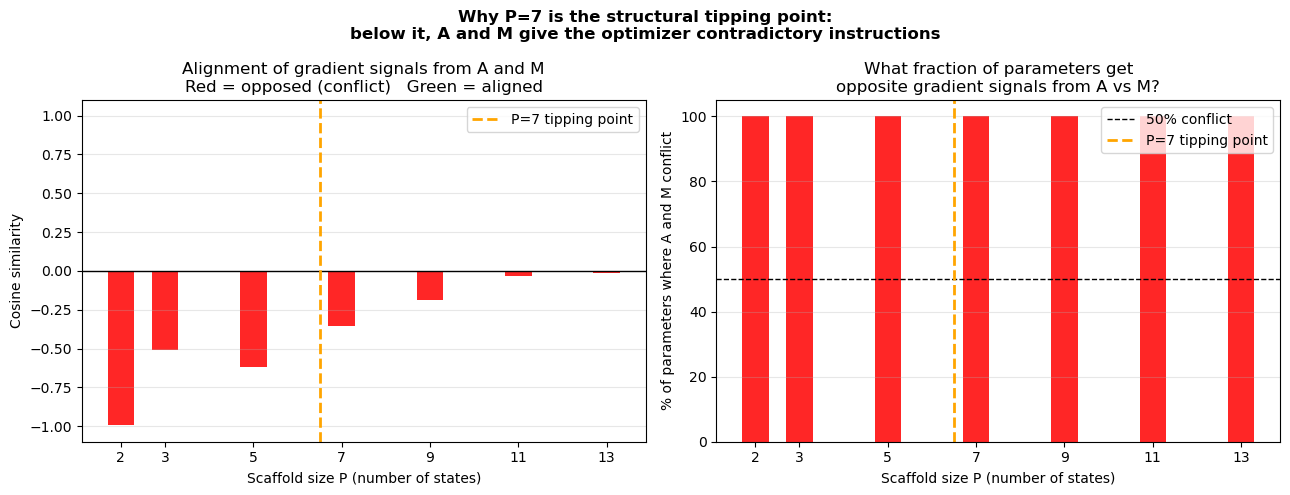

In [30]:
# ── Figure: two panels showing the tipping point ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

Ps           = [r["P"] for r in results]
cos_sims     = [r["cos_sim"] for r in results]
frac         = [r["frac_conflict"] for r in results]

# Panel 1: cosine similarity between ∂A/∂θ and ∂M/∂θ
ax = axes[0]
colors = ["red" if c < 0 else "green" for c in cos_sims]
ax.bar(Ps, cos_sims, color=colors, width=0.6, alpha=0.85)
ax.axhline(0, color="k", lw=1)
ax.axvline(6.5, color="orange", lw=2, ls="--", label="P=7 tipping point")
ax.set_xticks(Ps)
ax.set_xlabel("Scaffold size P (number of states)")
ax.set_ylabel("Cosine similarity")
ax.set_title("Alignment of gradient signals from A and M\n"
             "Red = opposed (conflict)   Green = aligned")
ax.set_ylim(-1.1, 1.1)
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Panel 2: fraction of parameters in conflict
ax = axes[1]
colors2 = ["red" if f > 0.5 else "green" for f in frac]
ax.bar(Ps, [f*100 for f in frac], color=colors2, width=0.6, alpha=0.85)
ax.axhline(50, color="k", lw=1, ls="--", label="50% conflict")
ax.axvline(6.5, color="orange", lw=2, ls="--", label="P=7 tipping point")
ax.set_xticks(Ps)
ax.set_xlabel("Scaffold size P (number of states)")
ax.set_ylabel("% of parameters where A and M conflict")
ax.set_title("What fraction of parameters get\nopposite gradient signals from A vs M?")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.suptitle("Why P=7 is the structural tipping point:\n"
             "below it, A and M give the optimizer contradictory instructions",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()